# ❤️ Heart Attack Analysis (EDA)

## Exploratory Data Analysis using Python

### 📌 Project Overview

This project performs Exploratory Data Analysis (EDA) on a heart attack dataset to identify key health indicators associated with cardiovascular disease. The analysis includes data cleaning, statistical summaries, visualizations, and insights that help understand factors influencing heart attack risk.

### 🎯 Objectives

- Understand the structure of the dataset
- Clean and preprocess the data
- Analyze relationships between different health indicators
- Visualize important trends and patterns
- Draw meaningful insights from the data

### 🛠 Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [3]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
# Loading the dataset

data = pd.read_csv('heart.csv')
data.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
5,57,1,0,140,192.0,0,1,148.0,0.0,0.4,1,0,1,1
6,56,0,1,140,294.0,0,0,153.0,0.0,1.3,1,0,2,1
7,44,1,1,120,263.0,0,1,173.0,0.0,0.0,2,0,3,1
8,52,1,2,172,199.0,1,1,162.0,0.0,0.5,2,0,3,1
9,57,1,2,150,168.0,0,1,174.0,0.0,1.6,2,0,2,1


## 📂 Dataset Overview

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       324 non-null    int64  
 1   sex       324 non-null    int64  
 2   cp        324 non-null    int64  
 3   trtbps    324 non-null    int64  
 4   chol      321 non-null    float64
 5   fbs       324 non-null    int64  
 6   restecg   324 non-null    int64  
 7   thalachh  320 non-null    float64
 8   exng      321 non-null    float64
 9   oldpeak   324 non-null    float64
 10  slp       324 non-null    int64  
 11  caa       324 non-null    int64  
 12  thall     324 non-null    int64  
 13  output    324 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 35.6 KB


## 🧹 Data Cleaning

In [6]:
# checking and handling duplicate values
data.duplicated().sum()
data.drop_duplicates(inplace = True)

In [7]:
# checking and handling missing/ null values

data.isnull().sum()

mean_chol = data['chol'].mean()
data.chol.replace(np.nan,mean_chol,inplace = True)

mean_thalachh = data['thalachh'].mean()
data.thalachh.replace(np.nan,mean_thalachh,inplace = True)

mode_exng = data.exng.dropna().mode()[0]
data.exng.replace(np.nan, mode_exng, inplace = True)

data.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [8]:
# statistical summary for part of data

cols = ['age','trtbps','chol','thalachh']
stats = data[cols].describe().round(0)
print(stats.loc[['mean','std','25%','50%','75%']].rename(index = {'25%': 'Q1', 
                                                                 '50%': 'Median', '75%': 'Q3'}))

         age  trtbps   chol  thalachh
mean    54.0   132.0  246.0     150.0
std      9.0    18.0   51.0      23.0
Q1      48.0   120.0  212.0     134.0
Median  56.0   130.0  242.0     152.0
Q3      61.0   140.0  274.0     166.0


## 📊 Gender-wise Heart Attack Analysis

Heart attack risk by sex (0=Male, 1=Female):
 sex
0    0.750000
1    0.446602
Name: output, dtype: float64


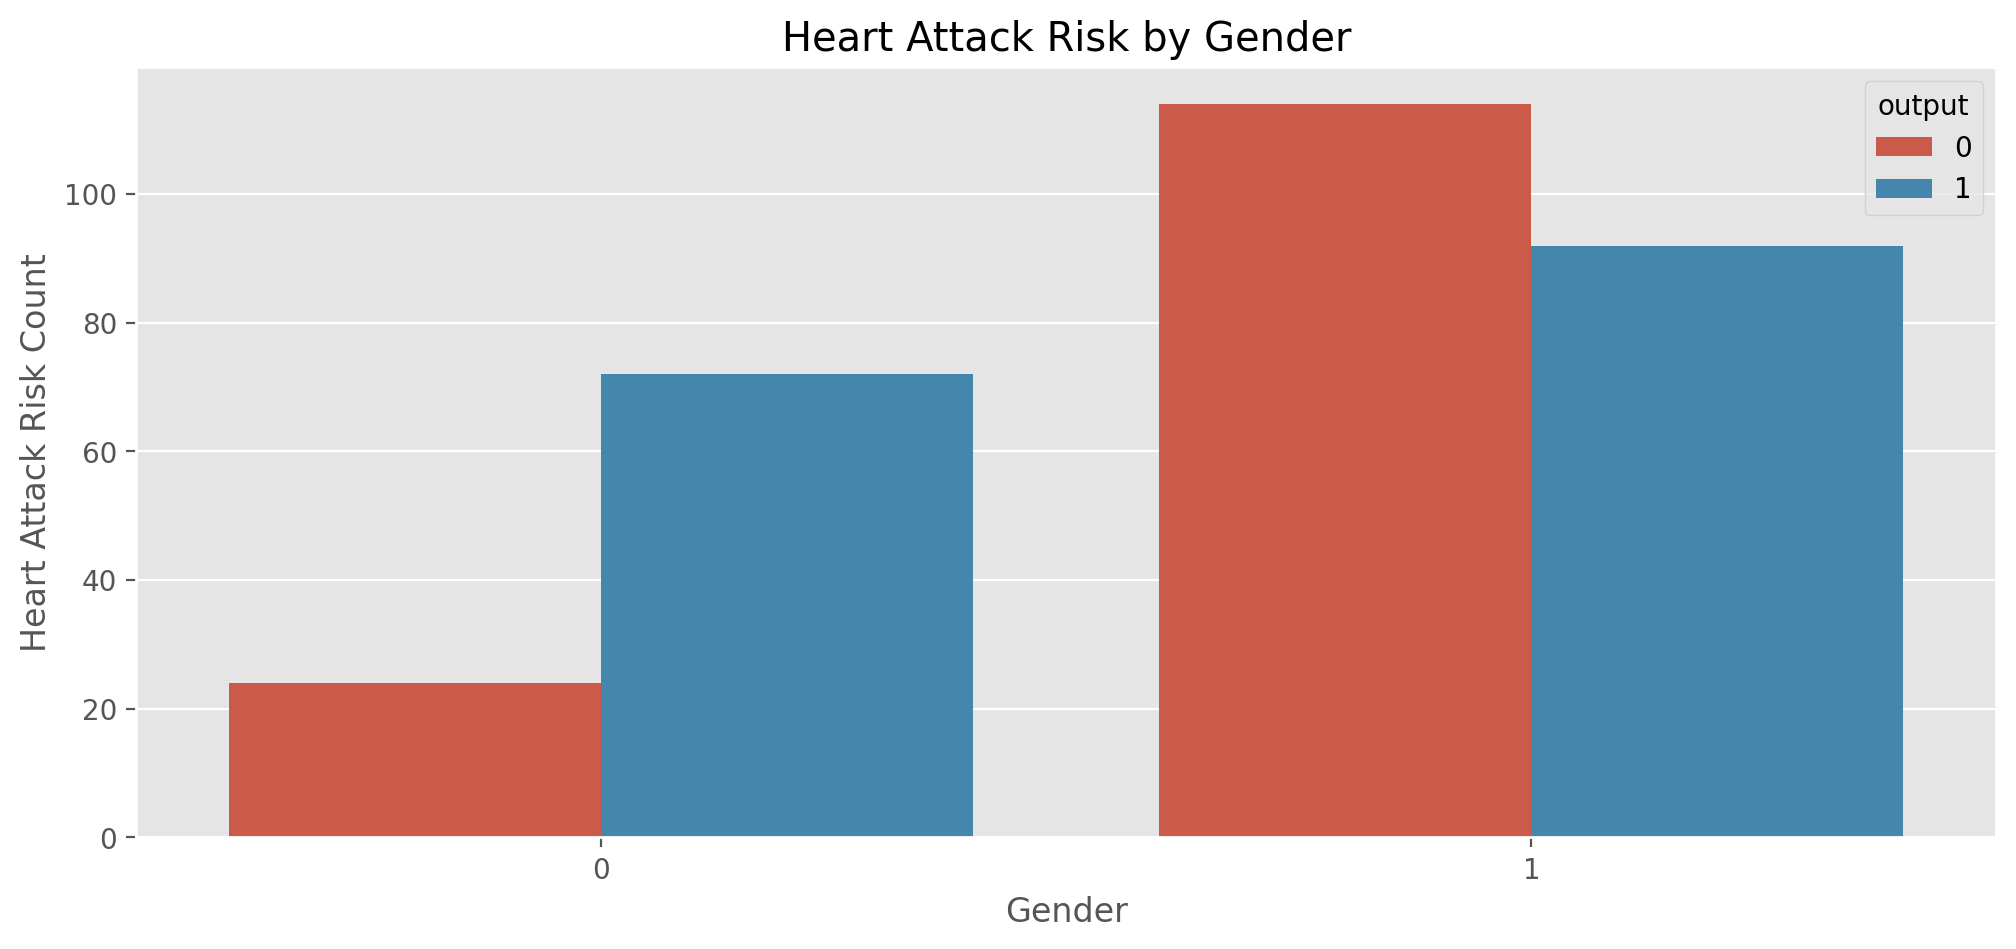

In [20]:
# Analysing heart attack risk by gender/sex

plt.figure(figsize = (12,5), dpi = 200)
sns.countplot(x = 'sex', hue = 'output',data = data)
plt.title('Heart Attack Risk by Gender')
plt.xlabel('Gender')
plt.ylabel('Heart Attack Risk Count')

hat_rate = data.groupby('sex')['output'].mean()
print(f"Heart attack risk by sex (0=Male, 1=Female):\n {hat_rate}")

## ❤️ Chest Pain Analysis

Heart attack risk by chest pain type:
 cp
0    0.272727
1    0.820000
2    0.790698
3    0.695652
Name: output, dtype: float64


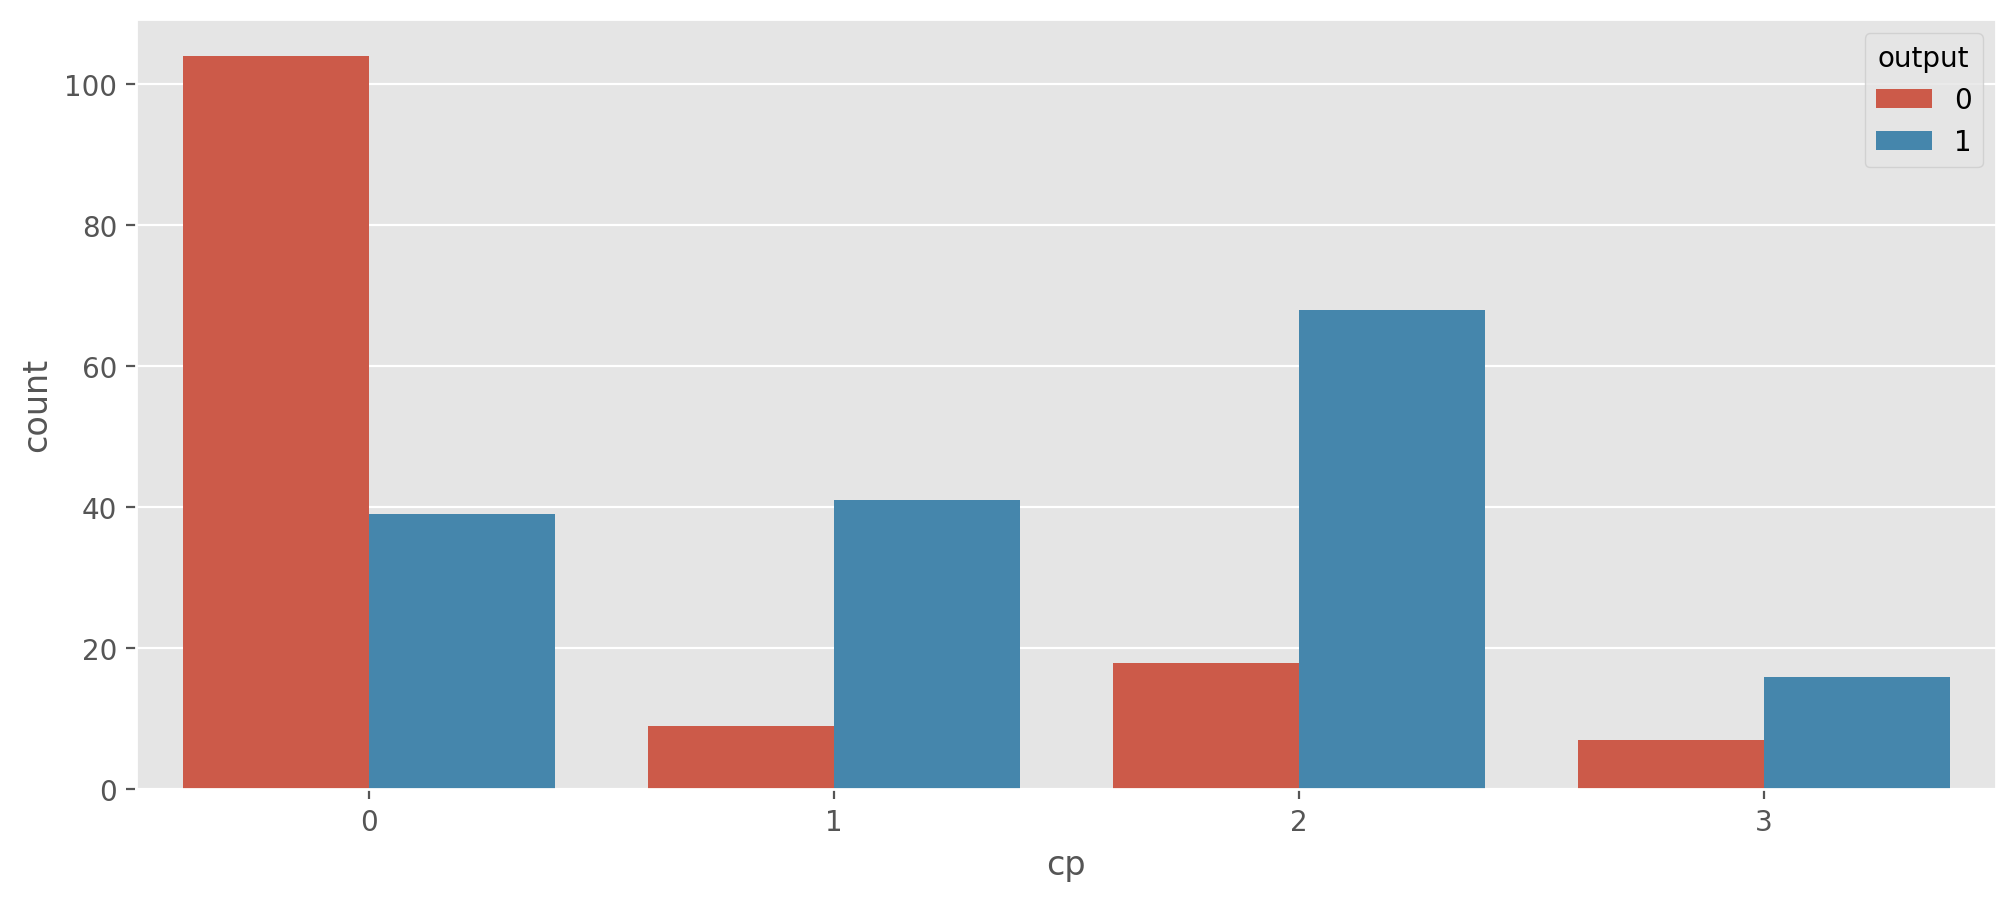

In [10]:
# Analysing heart attack risk by chest pain type
plt.figure(figsize = (12,5),dpi = 200)
sns.countplot(x = 'cp', hue = 'output', data = data )

hat_rate = data.groupby('cp')['output'].mean()
print(f"Heart attack risk by chest pain type:\n {hat_rate}")

## 👨 Age Analysis

output
0    56.601449
1    52.585366
Name: age, dtype: float64


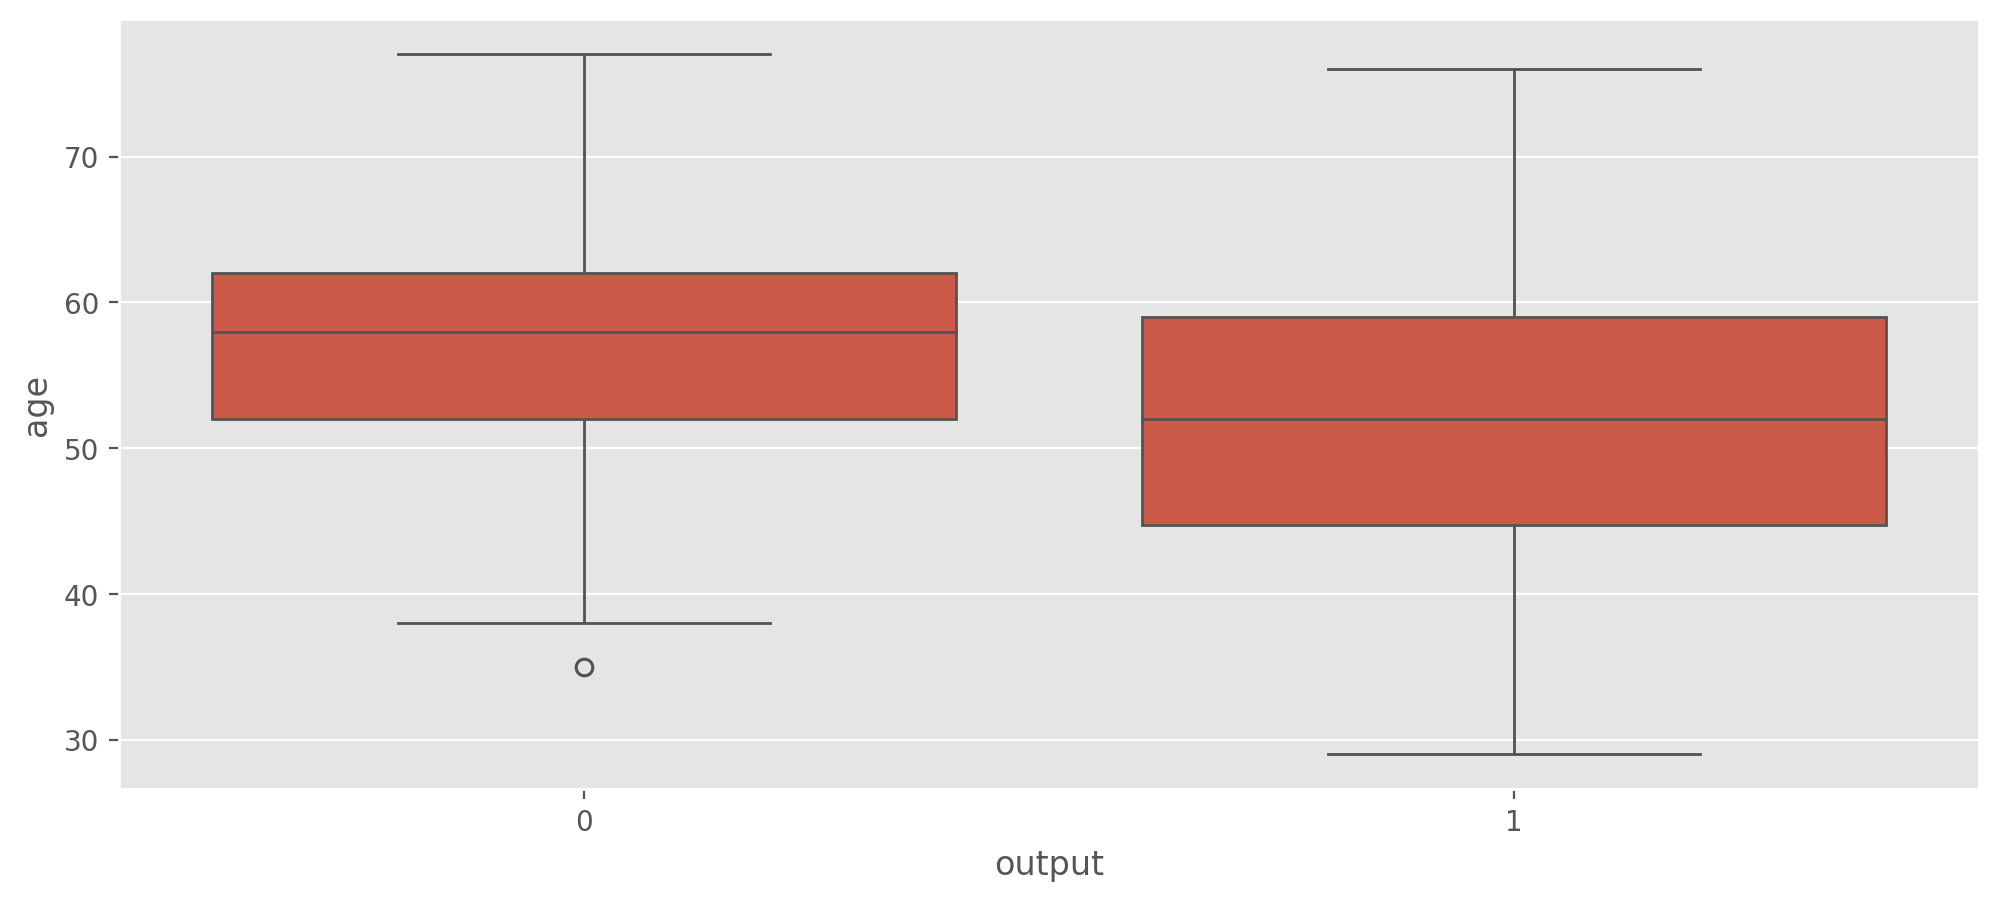

In [11]:
# Analysing the effect of age on heart attack risk
plt.figure(figsize = (12,5),dpi = 200)
sns.boxplot(y = 'age', x = 'output', data = data)

# Mean ages for comparison
hat_age = data.groupby('output')['age'].mean()
print(hat_age)

## 🩺 Fasting Blood Sugar Analysis

Heart attack risk by fasting blood sugar: 
 fbs
0    0.548638
1    0.511111
Name: output, dtype: float64


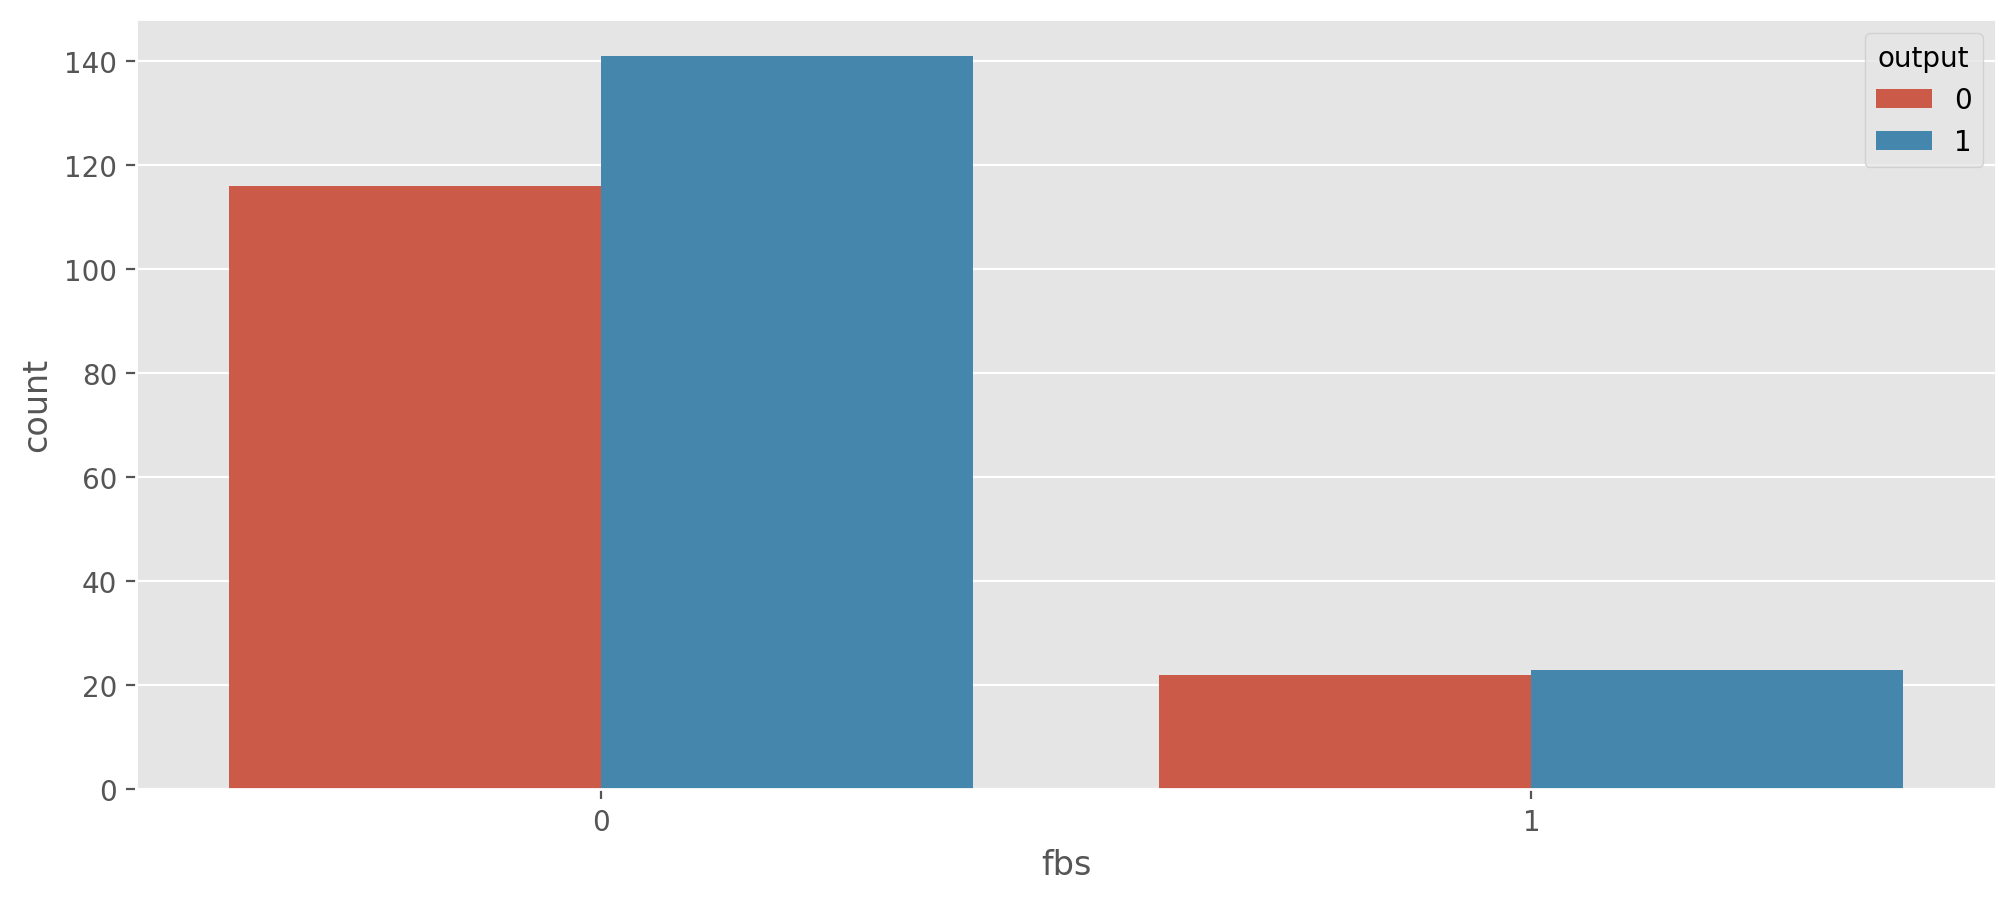

In [12]:
# Analysing does higher risk of heart attack is associated with 
# low or high fasting blood sugar levels
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot(x = 'fbs', hue = 'output', data = data)

hat_risk = data.groupby('fbs')['output'].mean()
print(f"Heart attack risk by fasting blood sugar: \n {hat_risk}")

## 📈 Resting ECG Analysis

Heart attack risk by resting ECG results: 
 restecg
0    0.462585
1    0.629139
2    0.250000
Name: output, dtype: float64


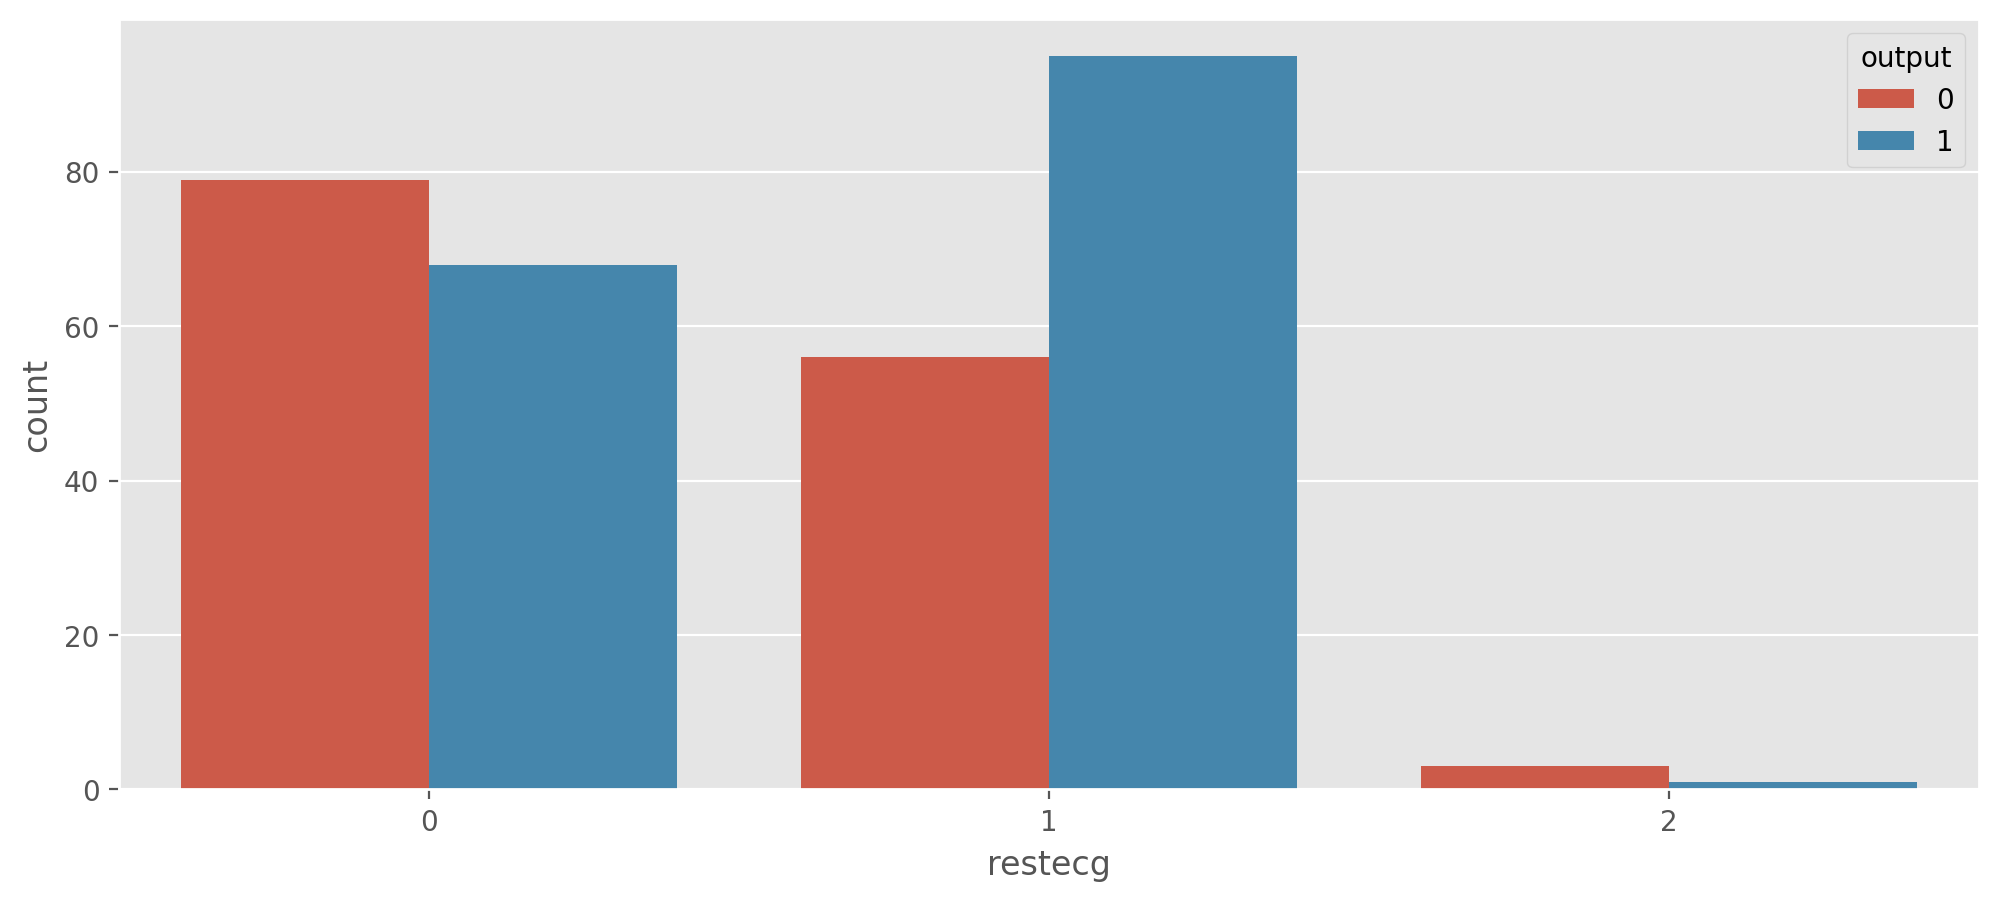

In [13]:
# Analysing heart attack risk by resting ecg
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot(x = 'restecg', hue = 'output', data = data)

hat_risk = data.groupby('restecg')['output'].mean()
print(f"Heart attack risk by resting ECG results: \n {hat_risk}")

## 🏃 Resting Blood Pressure Analysis

Mean blood pressure by risk:
output
0    134.398551
1    129.250000
Name: trtbps, dtype: float64


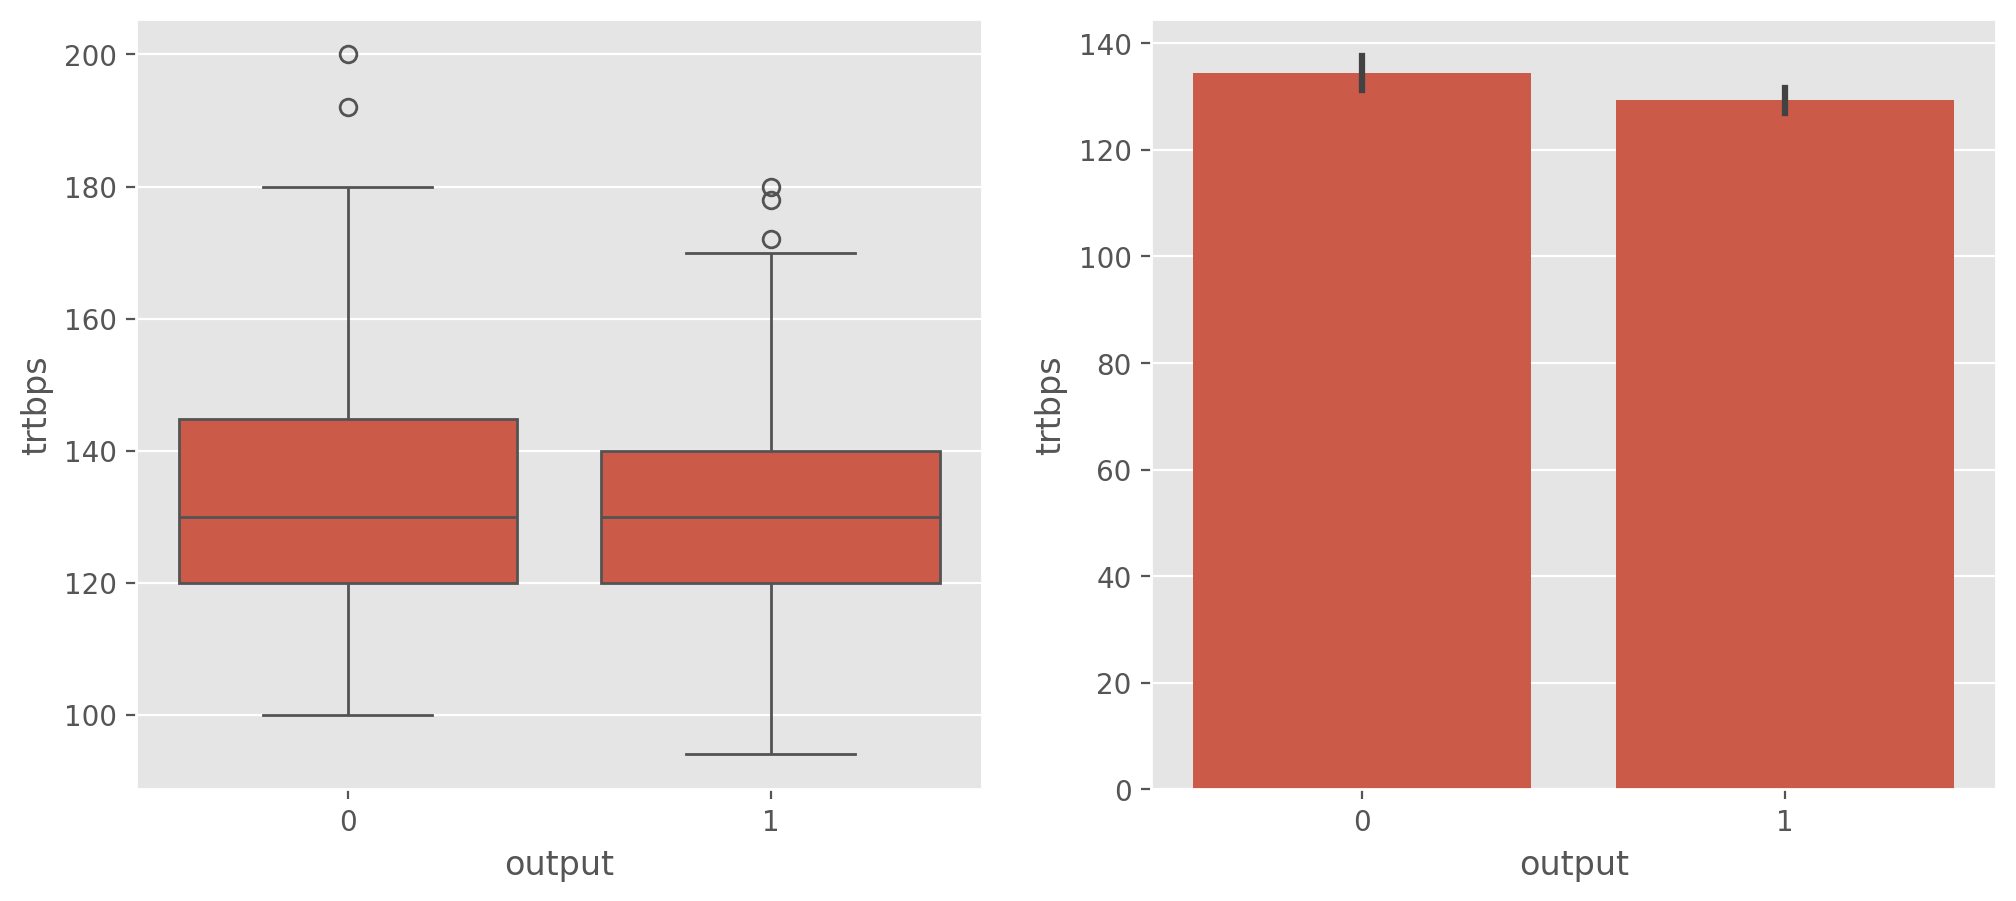

In [14]:
# Analysing does the resting blood pressure(trtbps) is a significant factor
# or not for determing risk of heart attack
plt.figure(figsize = (12,5),dpi = 200)
plt.subplot(1,2,1)
sns.boxplot(x = 'output', y = 'trtbps', data = data)
plt.subplot(1,2,2)
sns.barplot(x = 'output', y = 'trtbps', data = data)

hat_risk = data.groupby('output')['trtbps'].mean()
print(f"Mean blood pressure by risk:\n{hat_risk}")

## 🏃 Maximum Heart Rate Analysis

Mean heart rate by risk: 
output
0    139.101449
1    158.336512
Name: thalachh, dtype: float64


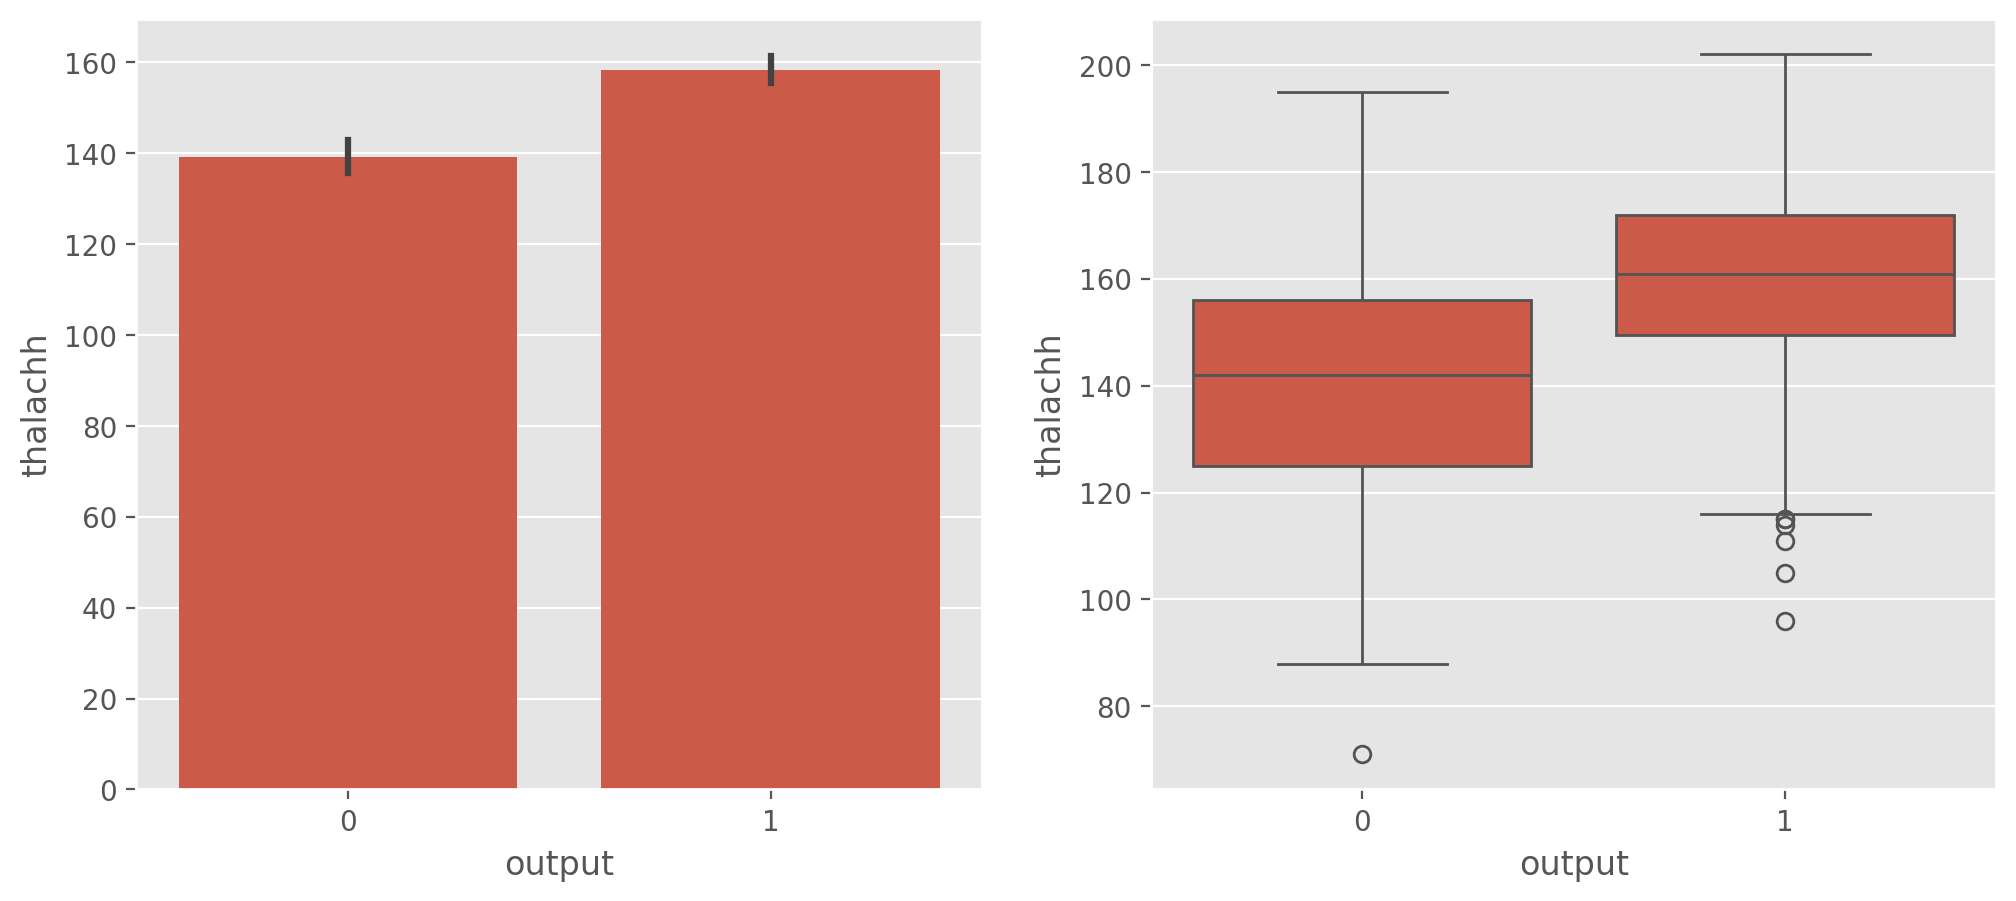

In [15]:
# Analysing does higher heart rate associated with heart attack risk

plt.figure(figsize = (12,5),dpi = 200)
plt.subplot(1,2,1)
sns.barplot(x = 'output', y = 'thalachh', data = data)
plt.subplot(1,2,2)
sns.boxplot(x = 'output', y = 'thalachh', data = data)

hat_risk = data.groupby('output')['thalachh'].mean()
print(f"Mean heart rate by risk: \n{hat_risk}")

## 📉 ST Segment Analysis

Heart attack risk by ST/HR slope:
 slp
0    0.428571
1    0.350000
2    0.751773
Name: output, dtype: float64


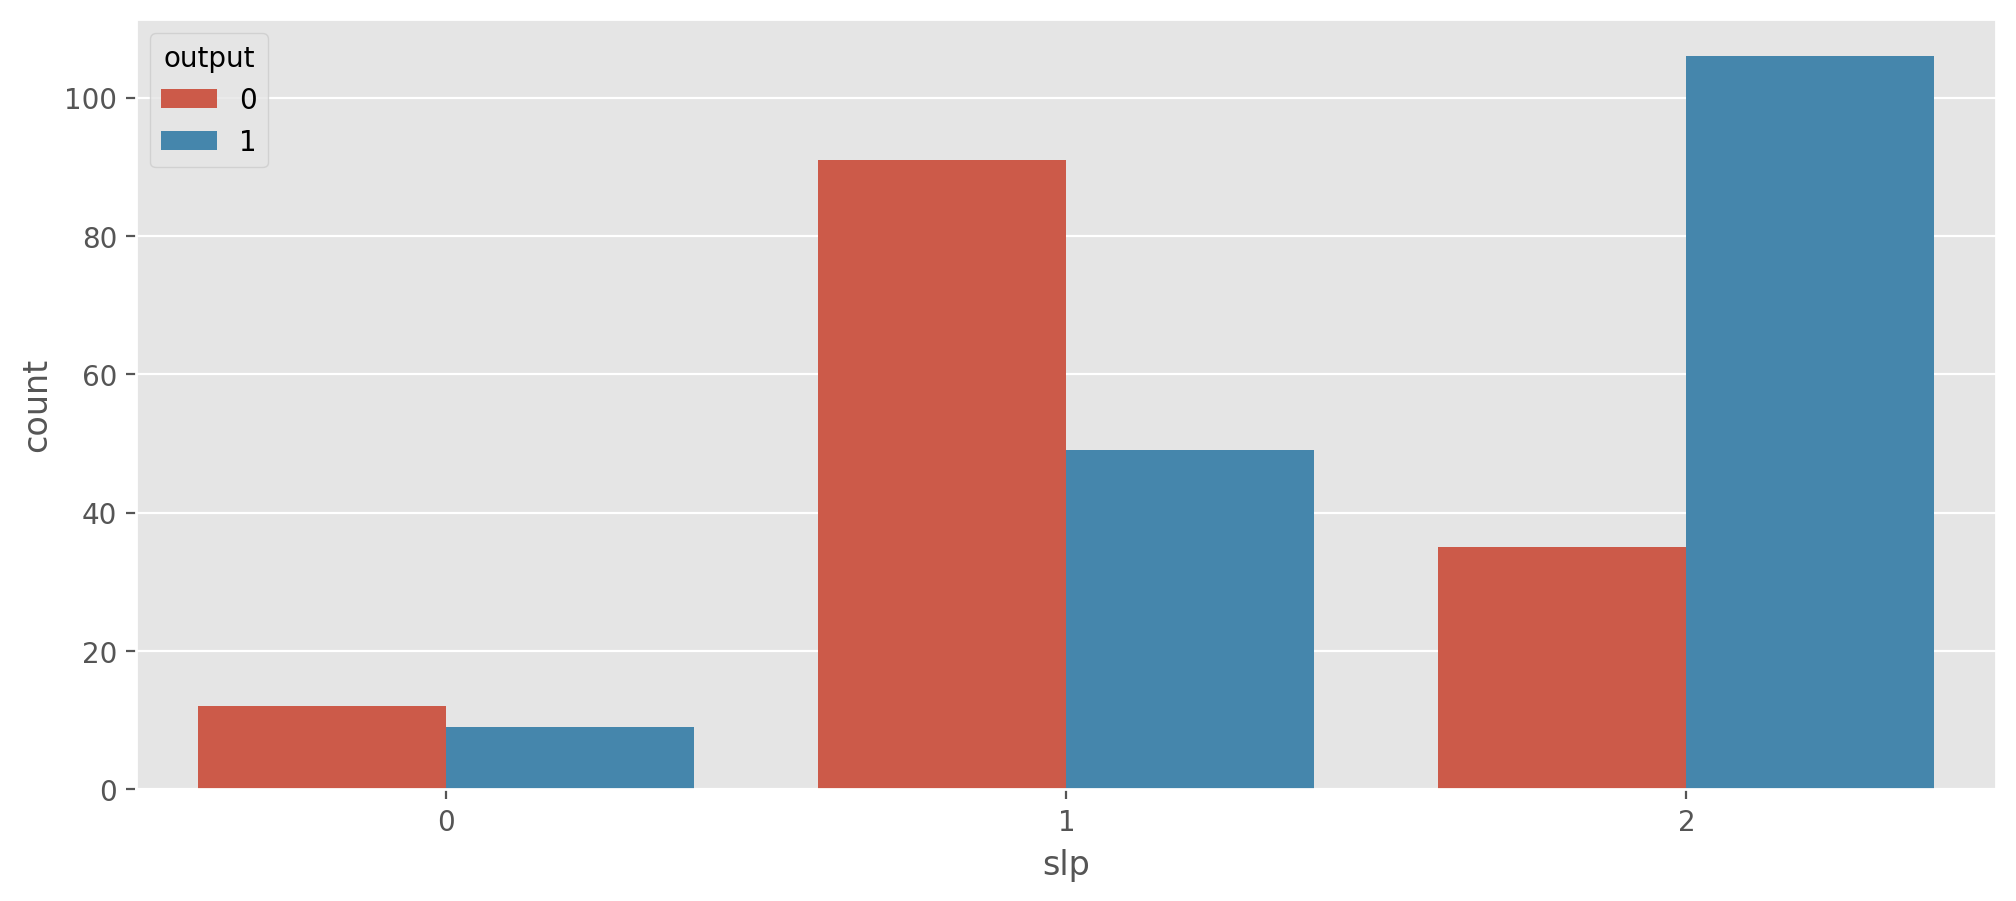

In [17]:
# Analysing the relationship between ST segment slope and heart attack risk
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot(x = 'slp', hue = 'output', data = data)

hat_risk = data.groupby('slp')['output'].mean()
print(f"Heart attack risk by ST/HR slope:\n {hat_risk}")